# **Qu'es ce que Naive Bayses ?**

Naive Bayes est une famille d'algorithmes probabilistes basés sur le théorème de Bayes, principalement utilisés pour des tâches de classification. Il suppose que les caractéristiques (ou attributs) des données sont conditionnellement indépendantes étant donné l'étiquette de classe, ce qui simplifie considérablement le calcul — d'où le terme "naïf".

Concepts Clés :
Théorème de Bayes : Au cœur de Naive Bayes se trouve le théorème de Bayes, qui dit :
P
(
A
∣
B
)
=
P
(
B
∣
A
)
⋅
P
(
A
)
P
(
B
)
P(A∣B)=
P(B)
P(B∣A)⋅P(A)
​


Types de Classificateurs Naive Bayes :
- Naive Bayes Gaussien : Suppose que les valeurs des caractéristiques continues suivent une distribution normale (gaussienne).
- Naive Bayes Multinomial : Utile pour les décomptes discrets, en particulier dans la classification de texte (ex. décomptes de mots).
- Naive Bayes Bernoulli : Conçu pour les caractéristiques binaires/booléennes (ex. si un mot est présent ou absent).

Applications :
Naive Bayes est couramment utilisé dans :

La classification de texte (détection de spam, analyse de sentiment)
La catégorisation de documents
Les systèmes de recommandation
Le diagnostic médical


Conclusion :
Naive Bayes est un algorithme de classification puissant et efficace, surtout dans des contextes où les hypothèses d'indépendance tiennent à peu près, ce qui en fait un choix populaire pour de nombreuses applications pratiques en apprentissage automatique et en traitement du langage naturel.

In [ ]:
# On importe les librairies
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,CategoricalNB
# - GaussianNB : Utilisé pour les données continues, basé sur la distribution normale
# - MultinomialNB : Adapté pour les données discrètes, souvent utilisé pour la classification de texte
# - CategoricalNB : Spécifiquement conçu pour des données catégorielles, comme illustré dans l'exemple ci-dessous

In [ ]:
# On importe le dataset
bd = pd.read_csv("titanic.csv")
bd.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


## Remarques sur le dataset

Certaines données ne sont pas pertinent :
PassendgerId, Name,SibSp,Parch Ticket Cabin,Embarked.

La donnée Sex est à transformer car elle est catégorique

Il faut vérifier si il n'y a pas des valeurs manquantes.

## Préparations des données ( data preprocessing )


### Trier les données

In [ ]:
# On supprime les données qui ne sont pas pertinents
bd.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True)
bd.head()

,Pclass,Sex,Age,Fare,Survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


### Séparer les données ( inputs ) des cibles (targets)

In [ ]:
# On sépare notre dataframe en deux les variable explicatives et la variable cible ( survived )
X = bd.drop('Survived',axis='columns')
Y = bd.Survived

### Traiter les variables catégoriques

### traiter les données manquantes

In [ ]:
# Identifions les variables qui contiennent des valeurs manquantes
X.columns[X.isna().any()]

Index(['Age'], dtype='object')

In [ ]:
X.describe()

,Pclass,Age,Fare
count,891.000000,714.000000,891.000000
mean,2.308642,29.699118,32.204208
std,0.836071,14.526497,49.693429
min,1.000000,0.420000,0.000000
25%,2.000000,20.125000,7.910400
50%,3.000000,28.000000,14.454200
75%,3.000000,38.000000,31.000000
max,3.000000,80.000000,512.329200


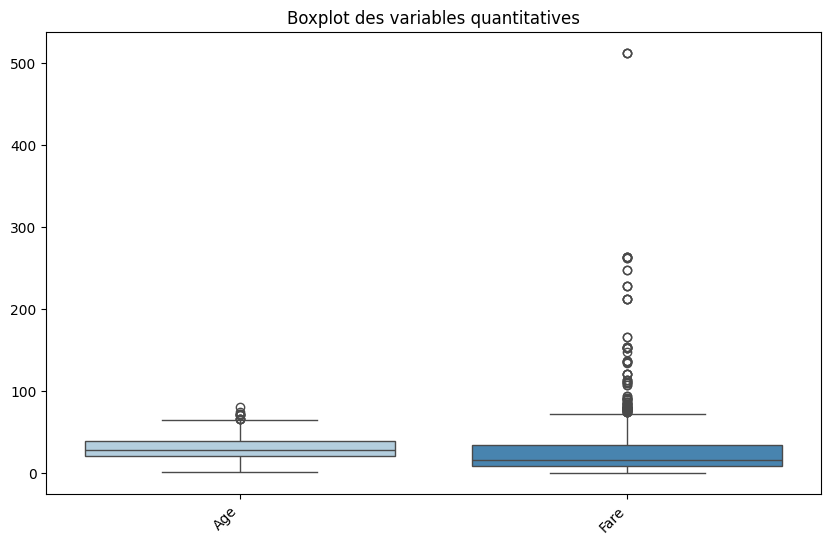

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# On supprime les colonnes non numériques et non pertinentes pour le boxplot
df_quanti = bd.drop(['Survived', 'Sex', 'Pclass'], axis=1)

# On vérifie s'il reste des valeurs manquantes et on les supprime (ou on les traite autrement si nécessaire)
df_quanti.dropna(inplace=True)

# On crée le boxplot avec la couleur bleue pour chaque variable quantitative
plt.figure(figsize=(10, 6))  # Ajustez la taille de la figure si nécessaire
sns.boxplot(data=df_quanti, palette="Blues") # Utilisation de la palette de couleurs 'Blues'
plt.title("Boxplot des variables quantitatives") # Ajout d'un titre au graphique
plt.xticks(rotation=45, ha='right') # Rotation des étiquettes de l'axe des x pour une meilleure lisibilité
plt.show()


In [ ]:
# remplacons les valeurs nulles par la médiane de chaque colonne correspondante.
X['Age'].fillna(X['Age'].median(), inplace=True)
X.describe()

<ipython-input-42-0bcff560599e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)


,Pclass,Age,Fare
count,891.000000,891.000000,891.000000
mean,2.308642,29.361582,32.204208
std,0.836071,13.019697,49.693429
min,1.000000,0.420000,0.000000
25%,2.000000,22.000000,7.910400
50%,3.000000,28.000000,14.454200
75%,3.000000,35.000000,31.000000
max,3.000000,80.000000,512.329200


In [ ]:
# encode la variable Sex
X['Sex'] = X['Sex'].map({'male': 1, 'female': 0})

In [ ]:
# Division de la base en ensemble train et test
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [ ]:
# Création du modèle de classification basé sur le Naïve Bayes pour des données catégorielles.
model = CategoricalNB()

In [ ]:
# Entrainement du model
model.fit(X_train,y_train)

CategoricalNB()

In [ ]:
# Évaluation de la performance du modèle sur l'ensemble de train
model.score(X_train,y_train)

0.8300561797752809

In [ ]:
# Évaluation de la performance du modèle sur l'ensemble de test
model.score(X_test,y_test)

0.7653631284916201

Le score du modèle, qui est de 0.765, indique généralement une performance assez bonne.

In [ ]:
# Predictions sur l'ensemble de test
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

# Calcul de l'exactitude
accuracy = accuracy_score(y_test, predictions)

# Affichage du résultat
print(f'Exactitude du modèle : {accuracy:.2f}')

Exactitude du modèle : 0.77


Le modèle a correctement prédit la classe des données dans 77 % des cas. Cela suggère que le modèle est relativement performant.

## NAIVE BAYES avec du texte


In [ ]:
# On importe le dataset
data = pd.read_csv("spam.csv")
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."




La première colonne (Category) indique si le message est "ham" (non spam) ou "spam" (indésirable).
La deuxième colonne (Message) contient le texte des messages eux-mêmes.

In [ ]:
# On importe CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
data.describe().T

,count,unique,top,freq
Category,5572,2,ham,4825
Message,5572,5157,"Sorry, I'll call later",30


<img src="images/vectorchart.png">

In [ ]:
# Crée une nouvelle colonne 'spam' dans le DataFrame 'data' où chaque entrée est 1 si la catégorie est 'spam' et 0 sinon.
data['spam']=data['Category'].apply(lambda x: 1 if x=='spam' else 0)
data.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.Message,data.spam)

In [ ]:
# transformer les données d'entraînement textuelles (X_train) en une matrice de comptes de mots
v = CountVectorizer()
X_train_count = v.fit_transform(X_train.values) # applique sur les valeurs de X_train
X_train_count.toarray()[:2] # convertir cette matrice en un tableau NumPy

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# Création d'un modèle de classification basé sur le Naïve Bayes.
model = MultinomialNB()
model.fit(X_train_count,y_train) # Entrainement

MultinomialNB()

In [ ]:
model.score(X_train_count,y_train)

0.9918640823163436

In [ ]:
X_test_count = v.transform(X_test) # Transformation de la base test
model.score(X_test_count, y_test)

0.9899497487437185

Le score du modèle, qui est de 0.9892318736539842, indique généralement une bonne performance.

Le pipeline va venir transformer nos données.

In [ ]:
from sklearn.pipeline import Pipeline
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [ ]:
# Entrainment du model
clf.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [ ]:
clf.score(X_test,y_test)

0.9899497487437185

Le score du modèle, qui est de 0.9899, indique généralement une bonne performance.